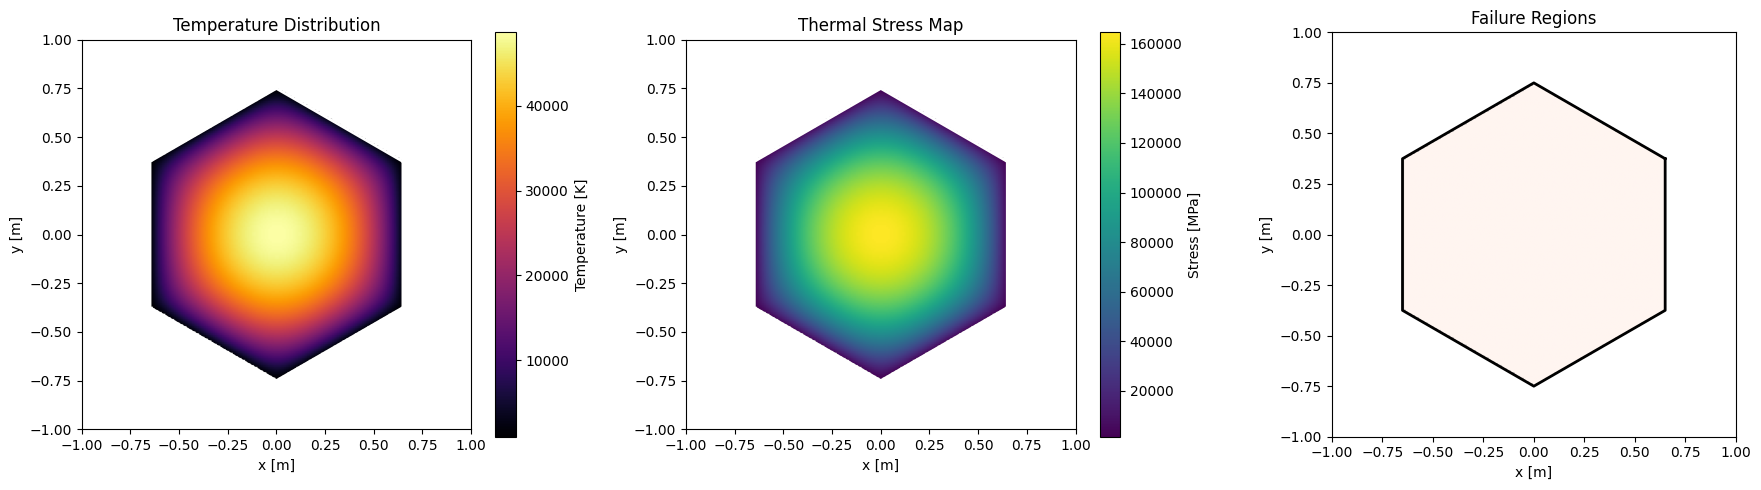


================ SIMULATION RESULTS ================

Maximum temperature : 48632.55 K
Minimum temperature : 600.00 K

Maximum stress      : 164683.03 MPa
Failure area        : 100.00 %




In [1]:
# ============================================================
# Fuel Element Thermal Stress Simulation
# ============================================================
# Author: OpenAI
# Description:
# 2D thermo-mechanical simulation of a hexagonal nuclear
# fuel element using finite differences and linear elasticity.
#
# Features:
# - Hexagonal geometry
# - Heat conduction
# - Thermal expansion
# - Thermal stress estimation
# - Failure point detection
# - High quality visualizations
#
# Requirements:
# pip install numpy matplotlib scipy
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.ndimage import gaussian_filter

# ============================================================
# 1. GEOMETRY
# ============================================================

N = 220
L = 1.0

x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)

dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y)

# ------------------------------------------------------------
# Hexagon vertices
# ------------------------------------------------------------

theta = np.linspace(0, 2*np.pi, 7)[:-1] + np.pi/6

R = 0.75

hex_vertices = np.column_stack([
    R * np.cos(theta),
    R * np.sin(theta)
])

hex_path = Path(hex_vertices)

points = np.vstack((X.flatten(), Y.flatten())).T

mask = hex_path.contains_points(points).reshape(N, N)

# ============================================================
# 2. THERMAL PHYSICS
# ============================================================

# Material properties
k = 25.0                  # thermal conductivity [W/m.K]
q = 2.5e7                 # volumetric heat generation [W/m^3]
T_coolant = 600.0         # boundary temperature [K]

# Temperature field initialization
T = np.ones((N, N)) * T_coolant

# ============================================================
# 3. SOLVE HEAT EQUATION
# ============================================================

# Steady-state heat conduction:
#
# ∇²T + q/k = 0
#

iterations = 3000

for it in range(iterations):

    T_old = T.copy()

    T[1:-1,1:-1] = 0.25 * (
        T_old[2:,1:-1] +
        T_old[:-2,1:-1] +
        T_old[1:-1,2:] +
        T_old[1:-1,:-2] +
        dx*dy*q/k
    )

    # Boundary condition
    T[~mask] = T_coolant

    # Smooth internal solution
    T = gaussian_filter(T, sigma=0.6)

# ============================================================
# 4. THERMAL EXPANSION
# ============================================================

alpha = 1.2e-5            # thermal expansion coefficient [1/K]

T_ref = T_coolant

delta_T = T - T_ref

thermal_strain = alpha * delta_T

# ============================================================
# 5. THERMAL STRESS
# ============================================================

# Linear elasticity approximation:
#
# σ = E α ΔT / (1 - ν)
#

E = 2.0e11                # Young modulus [Pa]
nu = 0.30                 # Poisson ratio

stress = E * alpha * delta_T / (1 - nu)

stress[~mask] = np.nan

# Von Mises-like simplified stress
von_mises = np.abs(stress)

# ============================================================
# 6. FAILURE ANALYSIS
# ============================================================

failure_limit = 3.5e8     # Pa

failure_map = von_mises > failure_limit

# ============================================================
# 7. VISUALIZATION
# ============================================================

plt.figure(figsize=(18,5))

# ------------------------------------------------------------
# Temperature field
# ------------------------------------------------------------

plt.subplot(1,3,1)

temp_plot = np.where(mask, T, np.nan)

im1 = plt.imshow(
    temp_plot,
    extent=[-L,L,-L,L],
    origin='lower',
    cmap='inferno'
)

plt.colorbar(im1, label='Temperature [K]')

plt.plot(
    np.append(hex_vertices[:,0], hex_vertices[0,0]),
    np.append(hex_vertices[:,1], hex_vertices[0,1]),
    'w',
    linewidth=2
)

plt.title('Temperature Distribution')
plt.xlabel('x [m]')
plt.ylabel('y [m]')

# ------------------------------------------------------------
# Thermal stress field
# ------------------------------------------------------------

plt.subplot(1,3,2)

im2 = plt.imshow(
    von_mises / 1e6,
    extent=[-L,L,-L,L],
    origin='lower',
    cmap='viridis'
)

plt.colorbar(im2, label='Stress [MPa]')

plt.plot(
    np.append(hex_vertices[:,0], hex_vertices[0,0]),
    np.append(hex_vertices[:,1], hex_vertices[0,1]),
    'white',
    linewidth=2
)

plt.title('Thermal Stress Map')
plt.xlabel('x [m]')
plt.ylabel('y [m]')

# ------------------------------------------------------------
# Failure points
# ------------------------------------------------------------

plt.subplot(1,3,3)

failure_display = np.where(failure_map, 1.0, np.nan)

plt.imshow(
    failure_display,
    extent=[-L,L,-L,L],
    origin='lower',
    cmap='Reds'
)

plt.plot(
    np.append(hex_vertices[:,0], hex_vertices[0,0]),
    np.append(hex_vertices[:,1], hex_vertices[0,1]),
    'black',
    linewidth=2
)

plt.title('Failure Regions')
plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.tight_layout()
plt.show()

# ============================================================
# 8. RESULTS
# ============================================================

print("\n================ SIMULATION RESULTS ================\n")

print(f"Maximum temperature : {np.nanmax(T):.2f} K")
print(f"Minimum temperature : {np.nanmin(T):.2f} K")

print(f"\nMaximum stress      : {np.nanmax(von_mises)/1e6:.2f} MPa")

failure_percentage = (
    np.nansum(failure_map) /
    np.sum(mask)
) * 100

print(f"Failure area        : {failure_percentage:.2f} %")

print("\n====================================================\n")
